In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('BankChurners.csv')
df = df.iloc[:, :-2]
df.drop(columns=['CLIENTNUM'], inplace=True)

df['Attrition_Flag'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

le = LabelEncoder()
for col in ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']:
    df[col] = le.fit_transform(df[col])

print("✅ Done! Shape:", df.shape)
print("Last 3 cols:", df.columns[-3:].tolist())
print(df['Attrition_Flag'].value_counts())

✅ Done! Shape: (10127, 20)
Last 3 cols: ['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Attrition_Flag'])
y = df['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("✅ Split done!")
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Churn ratio:", y_train.value_counts().to_dict())

✅ Split done!
Train: (8101, 19) | Test: (2026, 19)
Churn ratio: {0: 6799, 1: 1302}


In [3]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("✅ SMOTE done!")
print("Before:", y_train.value_counts().to_dict())
print("After :", y_train_res.value_counts().to_dict())

✅ SMOTE done!
Before: {0: 6799, 1: 1302}
After : {0: 6799, 1: 6799}


In [4]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
print("✅ Random Forest trained!")

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)
print("✅ XGBoost trained!")

✅ Random Forest trained!
✅ XGBoost trained!


In [5]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

for name, model in [("Random Forest", rf), ("XGBoost", xgb)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n========== {name} ==========")
    print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")


========== Random Forest ==========
              precision    recall  f1-score   support

    Retained       0.97      0.97      0.97      1701
     Churned       0.84      0.86      0.85       325

    accuracy                           0.95      2026
   macro avg       0.90      0.91      0.91      2026
weighted avg       0.95      0.95      0.95      2026

ROC-AUC Score: 0.9828
Confusion Matrix:
[[1647   54]
 [  47  278]]

========== XGBoost ==========
              precision    recall  f1-score   support

    Retained       0.98      0.98      0.98      1701
     Churned       0.89      0.90      0.90       325

    accuracy                           0.97      2026
   macro avg       0.94      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026

ROC-AUC Score: 0.9902
Confusion Matrix:
[[1666   35]
 [  33  292]]


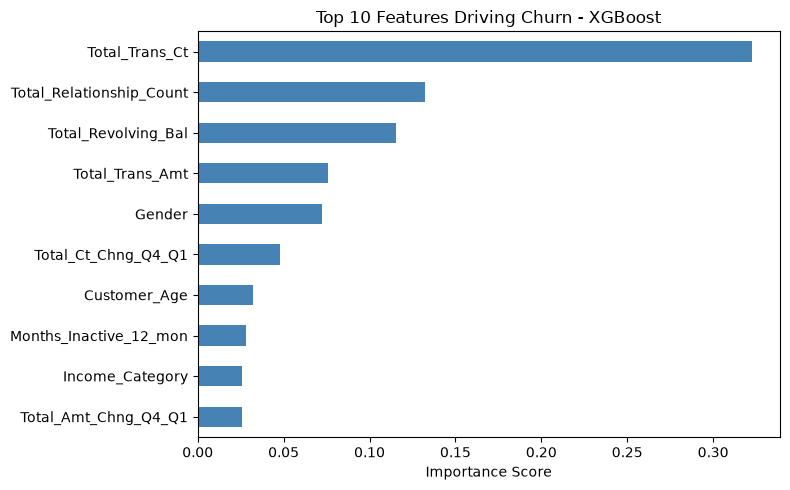

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp.nlargest(10).sort_values().plot(
    kind='barh', figsize=(8,5), color='steelblue'
)
plt.title('Top 10 Features Driving Churn - XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

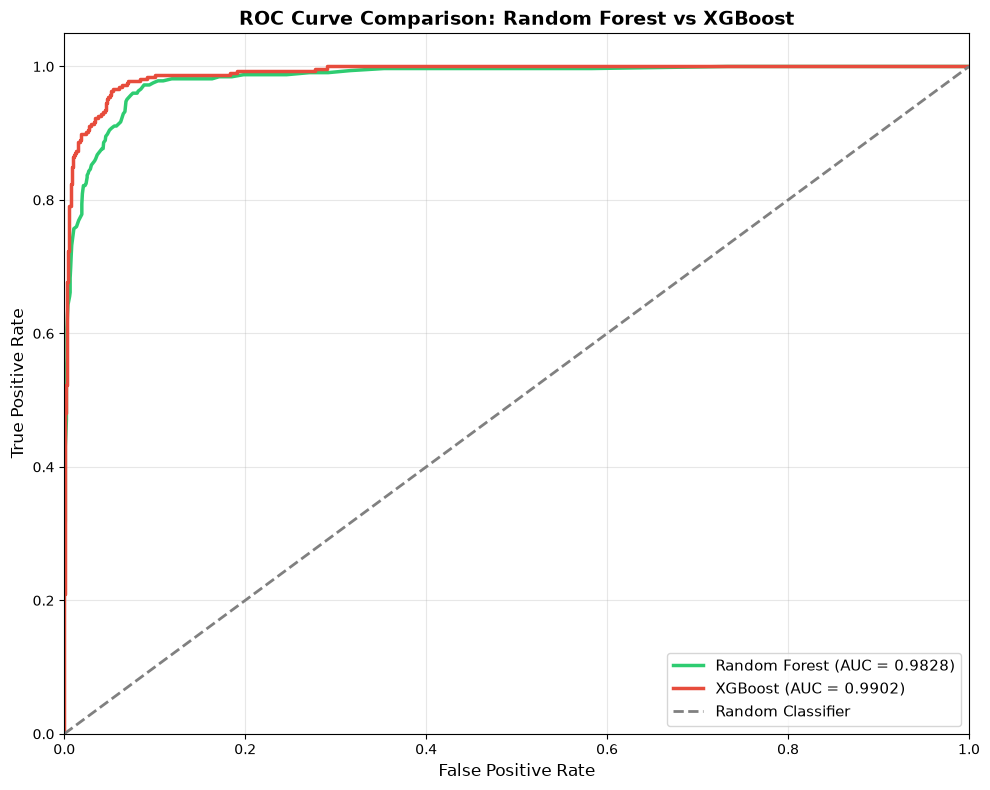

✅ ROC Curves Complete!
Random Forest AUC: 0.9828
XGBoost AUC: 0.9902


In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predictions and probabilities for both models
rf_proba = rf.predict_proba(X_test)[:, 1]
xgb_proba = xgb.predict_proba(X_test)[:, 1]

# Calculate ROC curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

# Calculate AUC scores
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, color='#2ecc71', lw=2.5, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, color='#e74c3c', lw=2.5, label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison: Random Forest vs XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ ROC Curves Complete!")
print(f"Random Forest AUC: {auc_rf:.4f}")
print(f"XGBoost AUC: {auc_xgb:.4f}")